# **17장. 트랜스포머를 활용한 이미지 모델**

### 트랜스포머는 순서나 위치가 의미를 가지는 어떤 유형의 데이터에도 적용할 수 있는 **범용 시퀀스 모델**입니다.  
> **텍스트, 이미지, 시계열, 악보(음표와 쉼표의 배열), DNA 염기 서열(A/T/G/C), 프로그래밍 코드 등**

> **적절한 토큰으로 변환하기만 하면 구조는 동일합니다.**


---



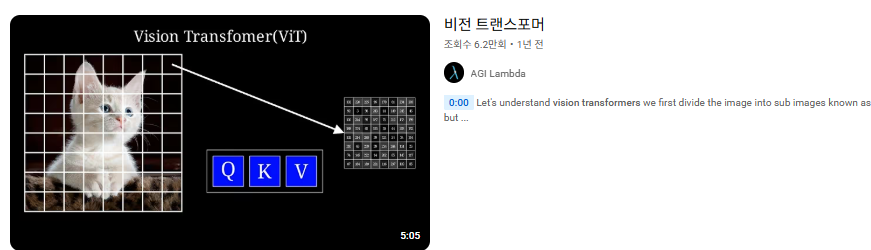

https://www.youtube.com/watch?v=vJF3TBI8esQ

이 동영상은 ViT 모델의 구조를 절 설명하고 있습니다. 처음 2분 30초만 시청해 봅시다.


---



In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling1D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast # 데이터 증강용
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.1 MB/s eta 0:00:00


[실습 17-01]

In [ ]:
# 저자의 github에서 미리 만들어둔 트랜스포머용 클래스 불러오기
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
from mini_transformers import PatchEmbedding, TransformerBlock


--2026-04-27 02:59:55--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-04-27 02:59:56 (97.7 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



### 실습 데이터 불러오기(utk_faces)


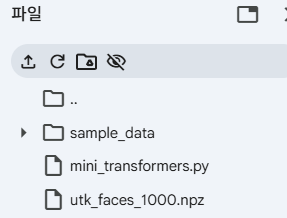

[실습 17-02]

In [ ]:
df = np.load("utk_faces_1000.npz")  # npz는 넘파이 어레이를 압축한 파일

X=df['X']; y=df['y']                # X(이미지)와 y(나이)를 분리

print("입력(이미지) 차원=",  X.shape)
print("타깃(나이) 차원=",  y.shape)


입력(이미지) 차원= (1000, 64, 64, 3)
타깃(나이) 차원= (1000,)


[실습 17-03]

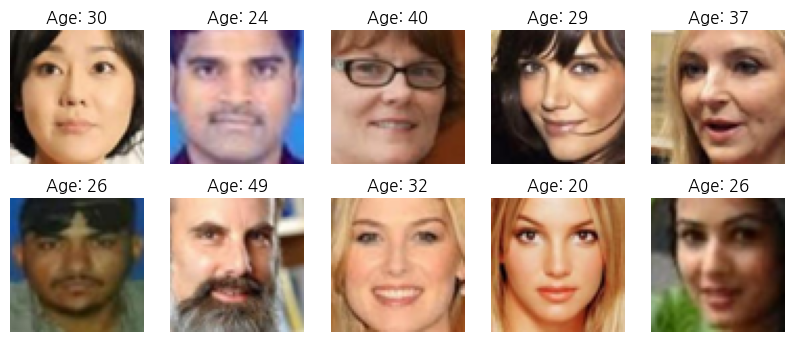

In [ ]:
# 처음 10개 이미지의 그림 출력
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)  # 4행 5열의 서브플롯
    plt.imshow(X[i])
    plt.axis("off")         # 축 숨기기
    plt.title(f"Age: {y[i]}")
plt.show()

[실습 17-04]

In [ ]:
X=X/255 # 이미지 데이터 정규화

SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("훈련셋 형태:", x_train.shape, y_train.shape)
print("검증셋 형태:", x_test.shape, y_test.shape)

훈련셋 형태: (800, 64, 64, 3) (800,)
검증셋 형태: (200, 64, 64, 3) (200,)


## ViT 모델 설정

* 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.


[실습 17-05]

In [ ]:
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# 하이퍼파라미터 설정
patch_size=8
embed_dim=64  # 임베딩 차원
num_heads=4   # 헤드 수

ViT=Sequential([
    Input(shape=x_train[0].shape),

    # 온라인 데이터 증강
    RandomFlip("horizontal"),
    #RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1),

    # 임베딩+포지션_인코딩
    PatchEmbedding(patch_size, embed_dim),

    # 셀프어텐션+FFN
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),

    # 각 패치 토큰의 벡터 요약
    #GlobalAveragePooling1D(),
    Flatten(),

    # 완전연결망으로 연결
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')
    ])

early_stop= EarlyStopping(monitor='val_loss',
                          patience=30, restore_best_weights=True)

ViT.compile(loss='mse',
            optimizer='adam',
            metrics=['mae'])

history = ViT.fit(x_train, y_train, validation_data=(x_test, y_test),
                  epochs=300,
                  batch_size=64,
                  callbacks=[early_stop])

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 387.2856 - mae: 15.2857 - val_loss: 126.0635 - val_mae: 10.0419
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 110.0967 - mae: 8.0093 - val_loss: 78.9147 - val_mae: 6.6976
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 93.9913 - mae: 7.4655 - val_loss: 76.7905 - val_mae: 6.9678
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 91.4621 - mae: 7.4010 - val_loss: 74.1879 - val_mae: 6.7078
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 84.6740 - mae: 7.0143 - val_loss: 73.0302 - val_mae: 6.5444
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 90.5102 - mae: 7.3081 - val_loss: 71.3915 - val_mae: 6.5057
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 94.5060 - mae: 7.2755 - val_loss: 70.3952 - val_mae: 6.5472
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 86.8158 - mae: 7.1546 - val_loss: 69.9003 - val_mae: 6.2615
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━

[실습 17-06]

In [ ]:
# 얼리 스톱된 에포크의 val_mae 출력
results = ViT.evaluate(x_test, y_test, verbose=0)
print(f"조기 종료 시점의 검증셋 평균제곱오차(MSE) =  {results[0]:.3f}")
print(f"조기 종료 시점의 검증셋 평균절대오차(MAE) =  {results[1]:.3f}")

조기 종료 시점의 검증셋 평균제곱오차(MSE) =  24.869
조기 종료 시점의 검증셋 평균절대오차(MAE) =  3.829




---



## **ViT의 능력**

데이터와 모델 크기가 커질수록 성능 상한선에 도달하는 CNN과 달리, ViT는 데이터가 많을수록 성능이 비례해서 증가하는 **확장성**(Scalability)을 가지고 있습니다.

예를 들어 의료 분야의 고해상도 병리/CT 이미지 분석은 ViT의 장점이 극적으로 드러나는 분야입니다.

병리 조직 슬라이드 한 장은 크기가 100,000 x 100,000 픽셀에 달하는 초고해상도 데이터입니다.

암세포 하나만 보는 것이 아니라, 주변 정상 세포와의 관계, 조직 전체의 구조적 변화(전역 맥락)를 동시에 관찰해야 합니다.
* CNN은 국소 영역만 보느라 전체적인 맥락을 놓치기 쉬운 반면, ViT는 멀티헤드 어텐션을 통해 세포들의 연결 패턴을 정확히 잡아냅니다.